Active scene: scene1hdr
Bands: NIR=121, R=77, G=43, B=17


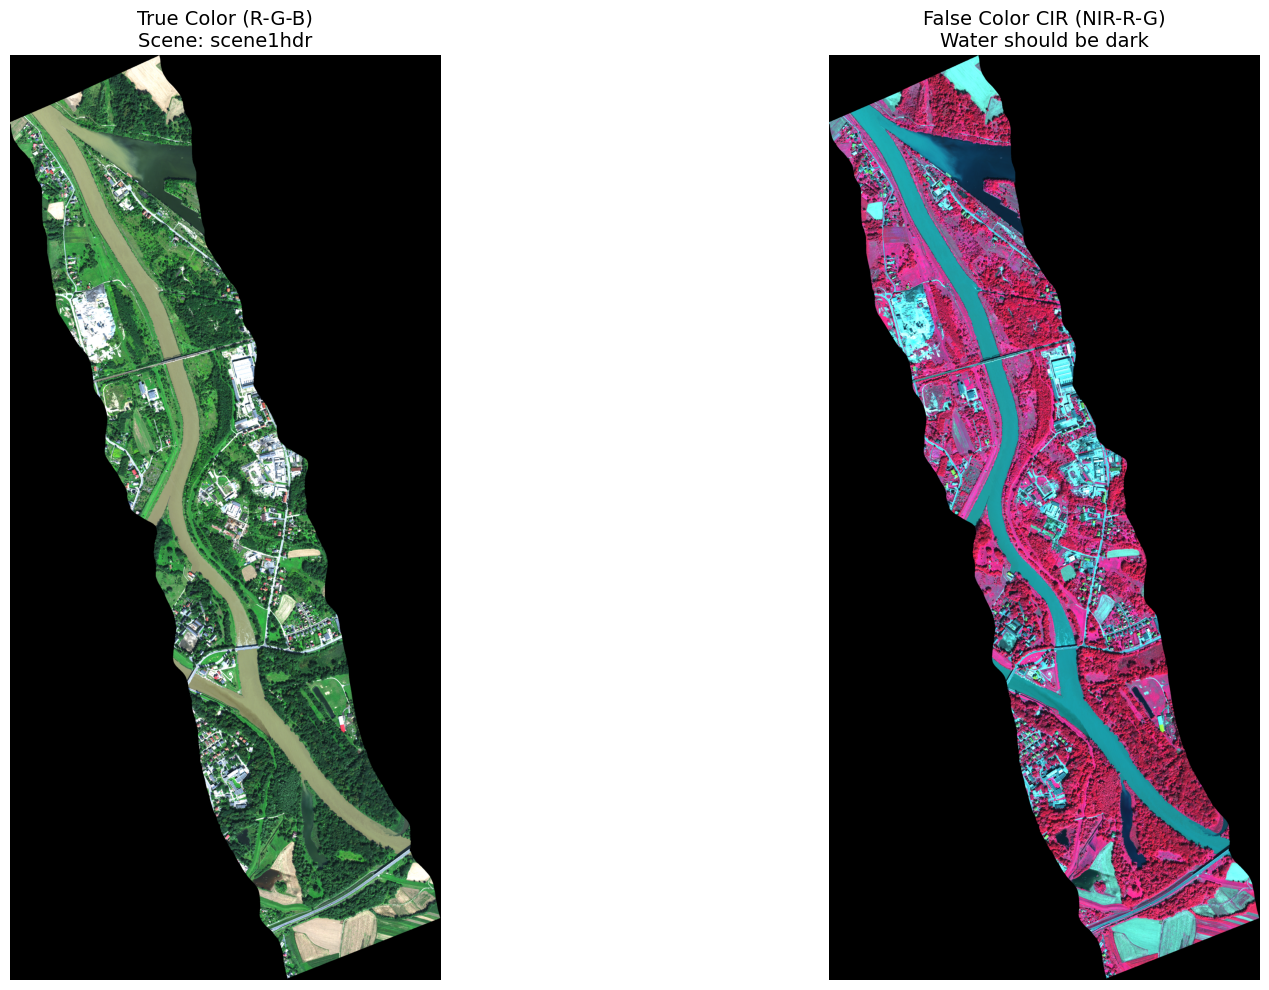

In [4]:
## Task 3.1
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import rasterio

if 'PROJ_LIB' in os.environ:
    del os.environ['PROJ_LIB']

# json config
with open('local_config.json', 'r') as f:
    config = json.load(f)

# key to scene
print(f"Active scene: {active_scene_key}")

# helper functions

def get_band_idx(wavelength_list, target_nm):
    """Looks for spectral band."""
    return np.argmin(np.abs(np.array(wavelength_list) - target_nm))

def pstretch(rgb_array):
    """Scaling 2-98% for scenes (H, W, 3)."""
    stretched = np.zeros_like(rgb_array, dtype=np.float32)
    for i in range(3):
        band = rgb_array[:, :, i].astype(np.float32)
        p2, p98 = np.nanpercentile(band, (2, 98))
        # Zabezpieczenie przed dzieleniem przez zero
        stretched[:, :, i] = np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)
    return stretched

# spectral data input

# opening hdr file
img = envi.open(path_hdr)

# wavelength info from metadata
if 'wavelength' in img.metadata:
    wavelengths = [float(w) for w in img.metadata['wavelength']]
else:
    raise ValueError(".hdr file does not contain wavelength info!")

idx_nir   = get_band_idx(wavelengths, 800)
idx_red   = get_band_idx(wavelengths, 660)
idx_green = get_band_idx(wavelengths, 550)
idx_blue  = get_band_idx(wavelengths, 470)

print(f"Bands: NIR={idx_nir}, R={idx_red}, G={idx_green}, B={idx_blue}")

# loading only current bands to preserve RAM
rgb_data = img.read_bands([idx_red, idx_green, idx_blue])
cir_data = img.read_bands([idx_nir, idx_red, idx_green])

# processing
# contrast
rgb_display = pstretch(rgb_data)
cir_display = pstretch(cir_data)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(rgb_display)
axes[0].set_title(f"True Color (R-G-B)\nScene: {active_scene_key}", fontsize=14)
axes[0].axis('off')

axes[1].imshow(cir_display)
axes[1].set_title("False Color CIR (NIR-R-G)\nWater should be dark", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [3]:
# scene keys
# task 3.1
active_scene_key = "scene1hdr" #the number can be 1, 2 or 3
path_hdr = config['path_hdr'][active_scene_key]
# task 3.3
path_bsq = config['path_hdr']['scene1bsq']


In [5]:
import pystac_client
import planetary_computer
from rasterio.warp import transform_bounds
import datetime

# 1. Connect to the STAC catalogue
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# 2. Extract Bounding Box from your Airborne data
# STAC search requires coordinates in WGS84 (Lat/Lon), not PL-2000 meters.
with rasterio.open(config['path_hdr'][active_scene_key.replace('hdr', 'bsq')]) as src:
    airborne_crs = src.crs
    airborne_bounds = src.bounds
    # Transform bounds to degrees for the search
    bbox_wgs84 = transform_bounds(airborne_crs, 'EPSG:4326', *airborne_bounds)

print(f"Searching for Sentinel-2 within BBOX: {bbox_wgs84}")

# 3. Search parameters
target_date = datetime.date(2025, 6, 17) # Your flight date
search_window = f"{target_date - datetime.timedelta(days=3)}/{target_date + datetime.timedelta(days=3)}"

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_wgs84,
    datetime=search_window,
    query={"eo:cloud_cover": {"lt": 10}} # Filter out cloudy images
)

items = search.item_collection()

if len(items) == 0:
    raise ValueError("No Sentinel-2 scenes found! Try increasing the search window or cloud limit.")

# 4. Pick the item closest to your flight date
best_item = min(items, key=lambda it: abs(it.datetime.date() - target_date))

print(f"SUCCESS: Found best_item -> {best_item.id}")
print(f"Acquisition date: {best_item.datetime.date()}")

Searching for Sentinel-2 within BBOX: (18.136726219401297, 50.3234799567054, 18.16496073322807, 50.36217592715419)
SUCCESS: Found best_item -> S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401
Acquisition date: 2025-06-15


Indices used: Chl-a(91/78), Turbidity(121), DOC(21/77)


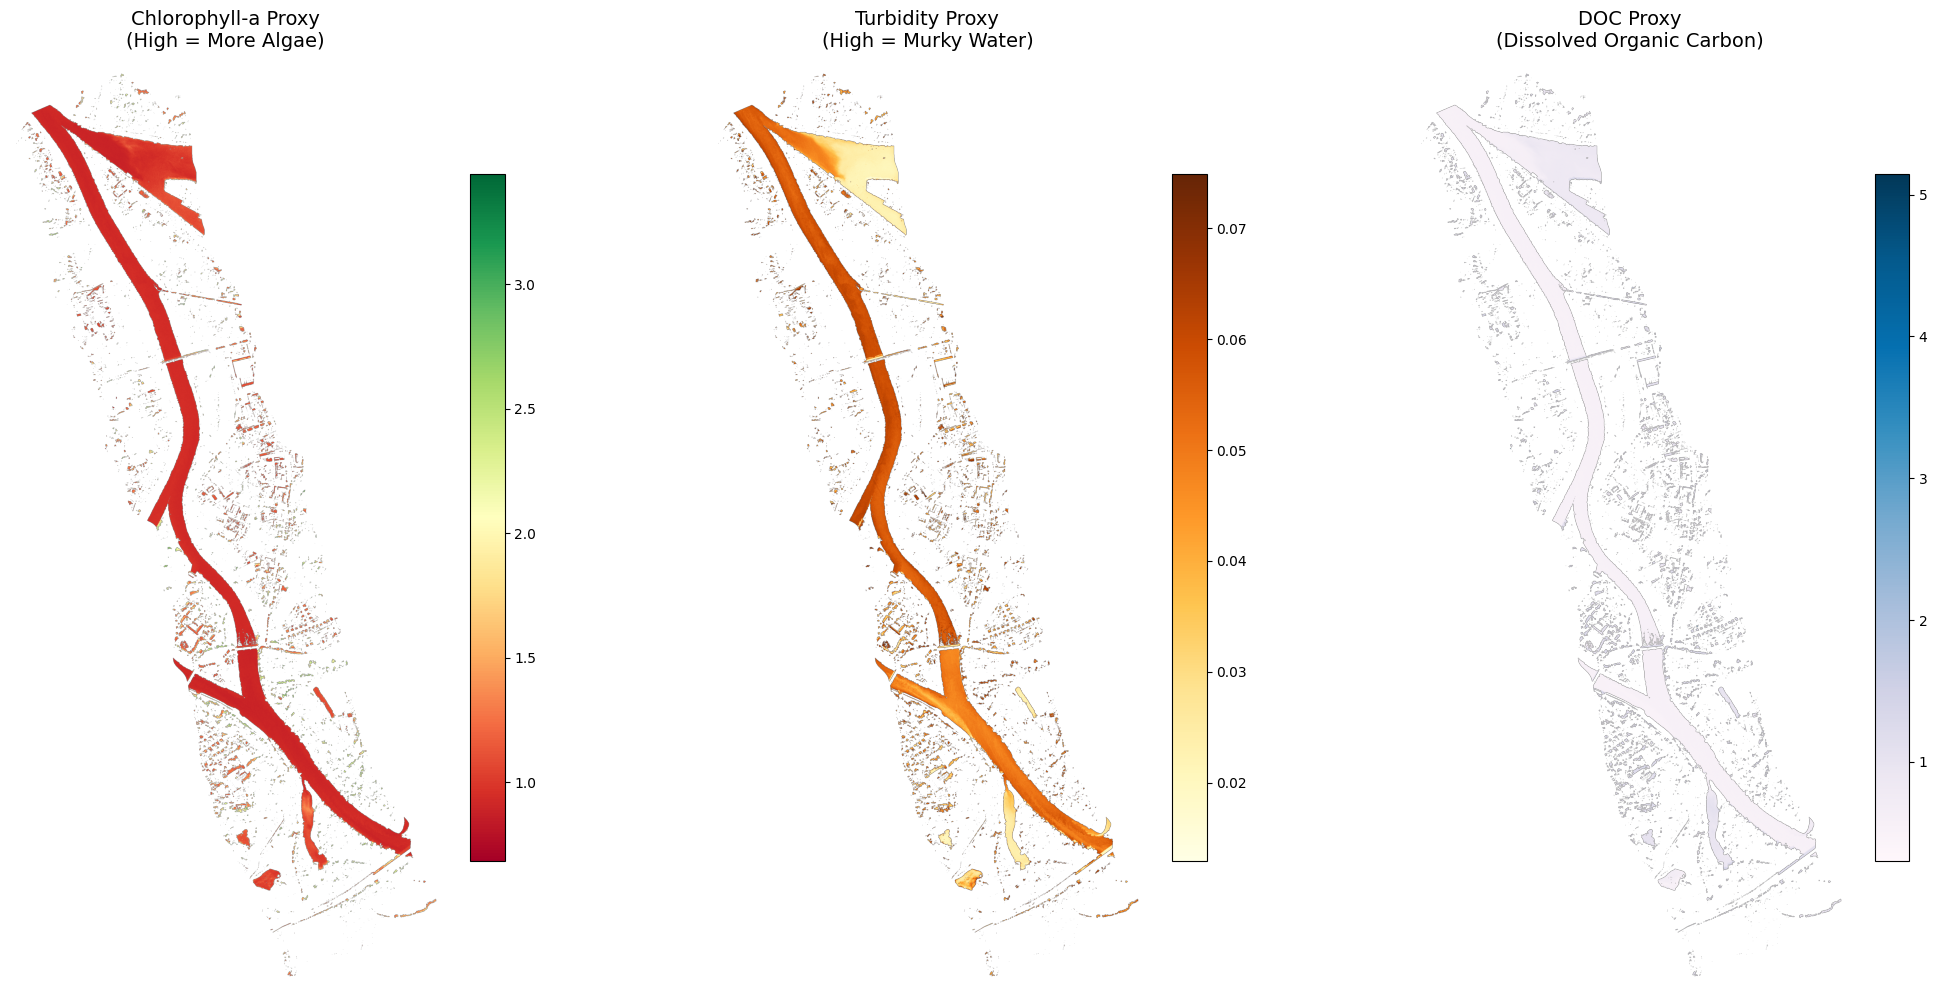

In [6]:
## Task 3.2
import numpy as np
import matplotlib.pyplot as plt

# target wavelengths
# Chl-a: Red-edge / Red ratio (Gitelson algorithm)
WL_CHLA_NUMERATOR = 705 
WL_CHLA_DENOMINATOR = 665

# Turbidity: NIR reflectance (water is brighter when turbid)
WL_TURBIDITY = 800 

# DOC: Blue / Red ratio (Dissolve Organic Carbon)
WL_DOC_NUMERATOR = 480
WL_DOC_DENOMINATOR = 660

# band indices
idx_705 = get_band_idx(wavelengths, WL_CHLA_NUMERATOR)
idx_665 = get_band_idx(wavelengths, WL_CHLA_DENOMINATOR)
idx_800 = get_band_idx(wavelengths, WL_TURBIDITY)
idx_480 = get_band_idx(wavelengths, WL_DOC_NUMERATOR)
idx_660 = get_band_idx(wavelengths, WL_DOC_DENOMINATOR)

print(f"Indices used: Chl-a({idx_705}/{idx_665}), Turbidity({idx_800}), DOC({idx_480}/{idx_660})")


# We read only the necessary bands to save RAM
bands_to_load = [idx_705, idx_665, idx_800, idx_480, idx_660, idx_nir]
data_subset = img.read_bands(bands_to_load).astype(np.float32)

# Extract specific bands from the loaded subset
b705 = data_subset[:, :, 0]
b665 = data_subset[:, :, 1]
b800 = data_subset[:, :, 2]
b480 = data_subset[:, :, 3]
b660 = data_subset[:, :, 4]
bnir = data_subset[:, :, 5] # NIR band for masking water

# water mask
NIR_WATER_THRESHOLD = 0.075
water_mask = (bnir > 0.0001) & (bnir < NIR_WATER_THRESHOLD)

# INDICES
# Use np.where to apply calculations only on water pixels
with np.errstate(divide='ignore', invalid='ignore'):
    # Chl-a Index (Relative)
    chl_a = np.where(water_mask, b705 / (b665 + 1e-6), np.nan)
    
    # Turbidity (NIR Reflection)
    turbidity = np.where(water_mask, b800, np.nan)
    
    # DOC Index
    doc = np.where(water_mask, b480 / (b660 + 1e-6), np.nan)

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Plot Chl-a
im1 = axes[0].imshow(chl_a, cmap='RdYlGn')
axes[0].set_title("Chlorophyll-a Proxy\n(High = More Algae)", fontsize=14)
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot Turbidity
im2 = axes[1].imshow(turbidity, cmap='YlOrBr')
axes[1].set_title("Turbidity Proxy\n(High = Murky Water)", fontsize=14)
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Plot DOC
im3 = axes[2].imshow(doc, cmap='PuBu')
axes[2].set_title("DOC Proxy\n(Dissolved Organic Carbon)", fontsize=14)
plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# this code is a helper for distinguishing water mask values
print(f"Minimum value in NIR: {np.nanmin(bnir)}")
print(f"Maximum value in NIR: {np.nanmax(bnir)}")
valid_data = bnir[bnir > 0]
if valid_data.size > 0:
    print(f"15th percentile (excluding zeros): {np.nanpercentile(valid_data, 15)}")
    print(f"20th percentile (median): {np.nanpercentile(valid_data, 20)}")

Minimum value in NIR: -9.999999747378752e-05
Maximum value in NIR: 1.5
15th percentile (excluding zeros): 0.05889999866485596
20th percentile (median): 0.07989999651908875


### This data was collected on 17th of June 2025

Aligning Sentinel-2 bands to Airborne grid...
 - Band B04 aligned.
 - Band B05 aligned.
 - Band B8A aligned.
 - Band B02 aligned.
 - Band B03 aligned.
 - Band B11 aligned.
 - Band B12 aligned.
Alignment complete. Ready to plot!


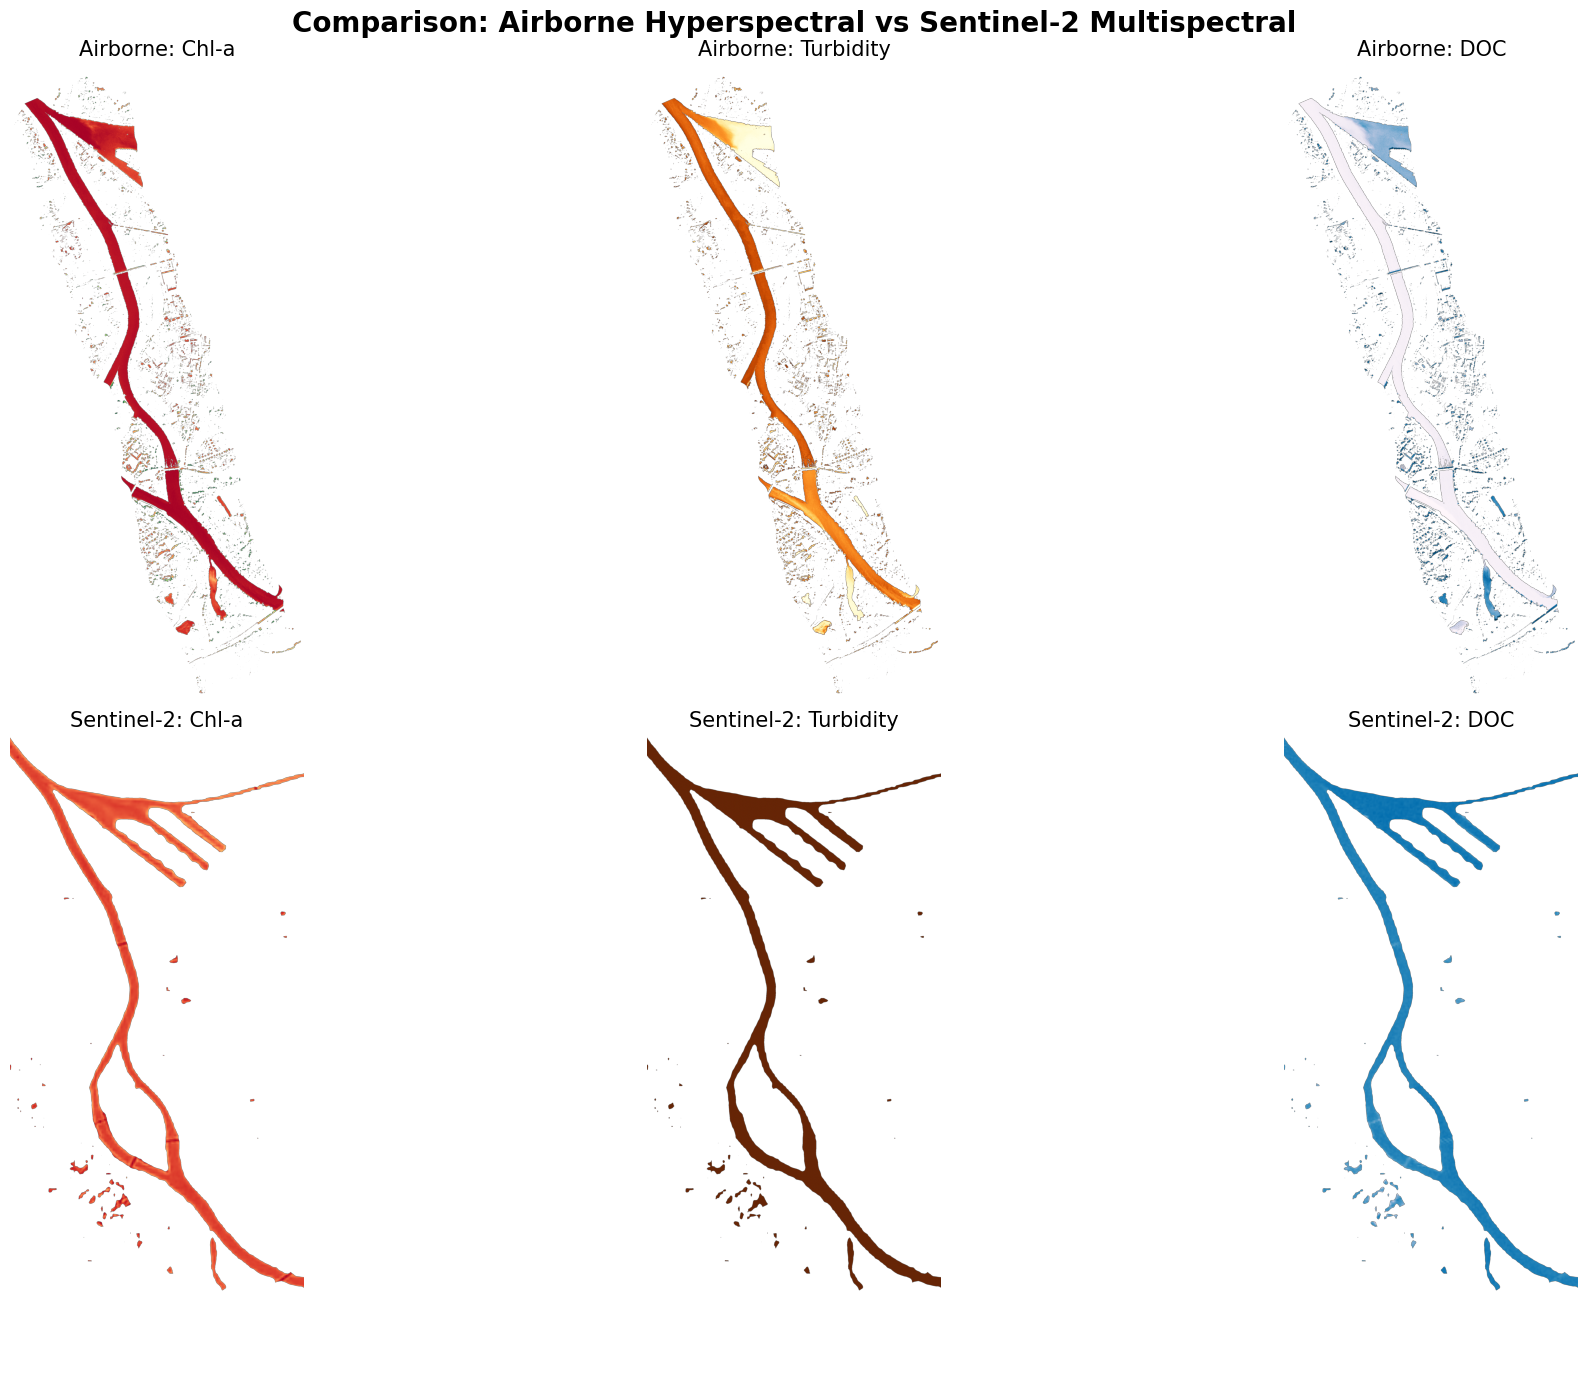

In [8]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# Make sure to use correct paths in the first cell of this notebook!!!

with rasterio.open(path_bsq) as master_src:
    out_shape = (master_src.height, master_src.width)
    out_transform = master_src.transform
    out_crs = master_src.crs
    
    # initialization of empty arrays for Sentinel-2 bands matching Airborne dimensions
    s2_aligned = {band: np.zeros(out_shape, dtype=np.float32) for band in ["B04", "B05", "B8A", "B02", "B03", "B11", "B12"]}

    print("Aligning Sentinel-2 bands to Airborne grid...")
    
    # for each band, download and reproject directly into the master grid
    for band in s2_aligned.keys():
        # get the signed URL from the best_item we found earlier
        s2_url = best_item.assets[band].href
        signed_url = planetary_computer.sign(s2_url)
        
        with rasterio.open(signed_url) as s2_src:
            reproject(
                source=rasterio.band(s2_src, 1),
                destination=s2_aligned[band],
                src_transform=s2_src.transform,
                src_crs=s2_src.crs,
                dst_transform=out_transform,
                dst_crs=out_crs,
                resampling=Resampling.bilinear
            )
        print(f" - Band {band} aligned.")

# conversion to 0-1 scale
# Sentinel-2 data is usually 0-10000
s2_red_final = s2_aligned["B04"] / 10000.0
s2_re_final = s2_aligned["B05"] / 10000.0
s2_nir_final = s2_aligned["B8A"] / 10000.0
s2_blue_final = s2_aligned["B02"] / 10000.0
#these will be used later
s2_green_final = s2_aligned["B03"] / 10000.0 
s2_swir1_final = s2_aligned["B11"] / 10000.0
s2_swir2_final = s2_aligned["B12"] / 10000.0

# index calculations
s2_water_mask = (s2_nir_final > 0.0001) & (s2_nir_final < 0.25) # threshold

with np.errstate(divide='ignore', invalid='ignore'):
    s2_chl_a = np.where(s2_water_mask, s2_re_final / (s2_red_final + 1e-6), np.nan)
    s2_turbidity = np.where(s2_water_mask, s2_nir_final, np.nan)
    s2_doc = np.where(s2_water_mask, s2_blue_final / (s2_red_final + 1e-6), np.nan)

print("Alignment complete. Ready to plot!")

# visualization
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# ROW 1: AIRBORNE
axes[0, 0].imshow(chl_a, cmap='RdYlGn', vmin=np.nanpercentile(chl_a, 2), vmax=np.nanpercentile(chl_a, 98))
axes[0, 0].set_title("Airborne: Chl-a", fontsize=15)

axes[0, 1].imshow(turbidity, cmap='YlOrBr', vmin=np.nanpercentile(turbidity, 2), vmax=np.nanpercentile(turbidity, 98))
axes[0, 1].set_title("Airborne: Turbidity", fontsize=15)

axes[0, 2].imshow(doc, cmap='PuBu', vmin=np.nanpercentile(doc, 2), vmax=np.nanpercentile(doc, 98))
axes[0, 2].set_title("Airborne: DOC", fontsize=15)

# ROW 2: SATELLITE 
axes[1, 0].imshow(s2_chl_a, cmap='RdYlGn', vmin=np.nanpercentile(chl_a, 2), vmax=np.nanpercentile(chl_a, 98))
axes[1, 0].set_title("Sentinel-2: Chl-a", fontsize=15)

axes[1, 1].imshow(s2_turbidity, cmap='YlOrBr', vmin=np.nanpercentile(turbidity, 2), vmax=np.nanpercentile(turbidity, 98))
axes[1, 1].set_title("Sentinel-2: Turbidity", fontsize=15)

axes[1, 2].imshow(s2_doc, cmap='PuBu', vmin=np.nanpercentile(doc, 2), vmax=np.nanpercentile(doc, 98))
axes[1, 2].set_title("Sentinel-2: DOC", fontsize=15)

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle("Comparison: Airborne Hyperspectral vs Sentinel-2 Multispectral", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

#### To ensure spatial alignment, Sentinel-2 multispectral bands were reprojected directly onto the airborne hyperspectral pixel grid using the airborne file's Affine Transform and CRS as a master template. This method accounts for the flight strip's rotation and prevents axis-swap errors in the PL-2000 coordinate system, allowing for a pixel-to-pixel comparison of water quality indices.

In [9]:
# task 3.4 - the calculations are in the cells above
import pandas as pd

# calculate means for water pixels only (ignoring NaNs)
comparison_data = {
    "Index": ["Chlorophyll-a", "Turbidity", "DOC"],
    "Airborne Mean": [np.nanmean(chl_a), np.nanmean(turbidity), np.nanmean(doc)],
    "Sentinel-2 Mean": [np.nanmean(s2_chl_a), np.nanmean(s2_turbidity), np.nanmean(s2_doc)]
}

df_compare = pd.DataFrame(comparison_data)
# difference column
df_compare["Diff (%)"] = ((df_compare["Sentinel-2 Mean"] - df_compare["Airborne Mean"]) / df_compare["Airborne Mean"]) * 100

print("--- NUMERICAL COMPARISON ---")
display(df_compare)

--- NUMERICAL COMPARISON ---


,Index,Airborne Mean,Sentinel-2 Mean,Diff (%)
0,Chlorophyll-a,1.101787,1.136557,3.155782
1,Turbidity,0.049281,0.165101,235.022110
2,DOC,0.700573,1.005847,43.574913


#### Looking at the Diff (%) we can observe the Sentinel-2 data is very poor for indicating water turbidity. It also shows poor quality when working don DOC indicator. Only on chlorophyll detection the Sentinel-2 data can be used as a substitute for airborne data.

## TASK 4: Spectral Angle Mapper (SAM)

### Step 1: Master indices library
We will use spectral indices created during task 2 to create Master indices for classes: forest, green, semiturbulent, soil, turbulent and water.

In [33]:
import pandas as pd
import glob
from pathlib import Path
import numpy as np

library_path = Path(r"D:\D_studia\semestr_8\remote_sensing\lab_5_spectra")
all_csvs = glob.glob(str(library_path / "*.csv"))

#loading samples
raw_samples = { "forest": [], "green": [], "semiturbulent": [], "soil": [], "turbulent": [], "water": [] }

for file_path in all_csvs:
    class_name = Path(file_path).stem.split('_')[0] 
    if class_name in raw_samples:
        df = pd.read_csv(file_path)
        raw_samples[class_name].append(df['value'].values)

#Median Reference Spectra at airborne resolution
reference_spectra_airborne = {}
for name, sigs in raw_samples.items():
    if len(sigs) > 0:
        reference_spectra_airborne[name] = np.nanmedian(np.array(sigs), axis=0)
        print(f"Class '{name}': {len(sigs)} samples loaded.")

class_list = list(reference_spectra_airborne.keys())
#full airborne signature matrix
ref_matrix_airborne = np.array([reference_spectra_airborne[name] for name in class_list])

Class 'forest': 9 samples loaded.
Class 'green': 9 samples loaded.
Class 'semiturbulent': 10 samples loaded.
Class 'soil': 10 samples loaded.
Class 'turbulent': 9 samples loaded.
Class 'water': 9 samples loaded.


### Step 2: Calibration
This cell transforms the 200-band airborne data into the 7-band Sentinel-2 format.

Calibration complete. Training set shape: (56, 7)


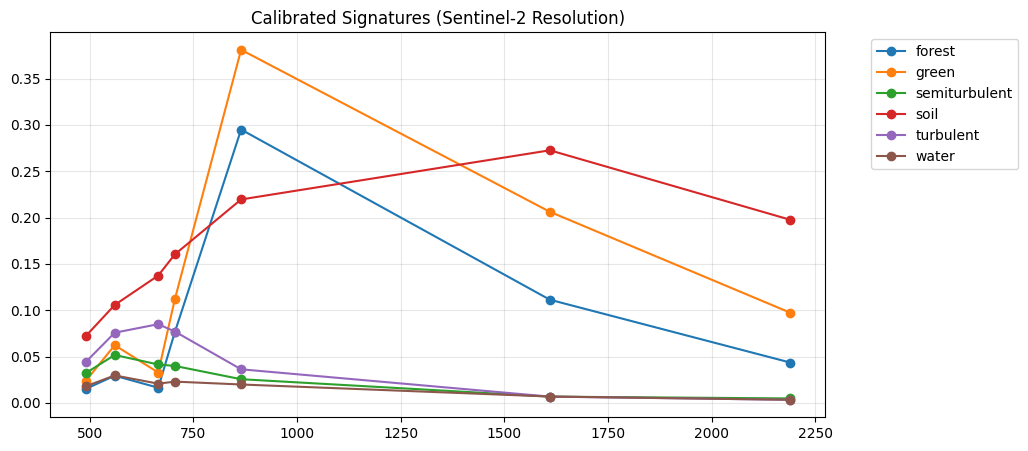

In [34]:
#sentinel-2 wavelengths
s2_wavelengths = [490, 560, 665, 705, 865, 1610, 2190] # B02, B03, B04, B05, B8A, B11, B12

#S2 bands to Airborne indices
s2_indices = [get_band_idx(wavelengths, wl) for wl in s2_wavelengths]

#calibrated library (resampled to 7 bands)
X_train_calibrated = []
y_train = []

class_to_id = {name: i for i, name in enumerate(class_list)}

for name in class_list:
    for sig in raw_samples[name]:
        X_train_calibrated.append(sig[s2_indices])
        y_train.append(class_to_id[name])

X_train = np.array(X_train_calibrated)
y_train = np.array(y_train)

calibrated_lib_s2 = ref_matrix_airborne[:, s2_indices]

print(f"Calibration complete. Training set shape: {X_train.shape}")

#calibrated signatures
plt.figure(figsize=(10, 5))
for i, name in enumerate(class_list):
    plt.plot(s2_wavelengths, calibrated_lib_s2[i], label=name, marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Calibrated Signatures (Sentinel-2 Resolution)")
plt.grid(alpha=0.3)
plt.show()

On the plot there are spectral signatures of all previously selected and loaded classes. Based on this plot we can observe:
* Forest and green signatures have the same shape. The only difference between them their reflectance (green class is brighter).
* Semiturbulent class is located between turbulent and water classes, which points out to good selection of sampling places.
* Soil class is the only one signature that is not alike any other class.

### Step 3: Classification
SAM calculations and classification.

In [38]:
#Sentinel-2 image data into a flat matrix
s2_pixels = np.stack([
    s2_blue_final, s2_green_final, s2_red_final, 
    s2_re_final, s2_nir_final, s2_swir1_final, s2_swir2_final
], axis=-1).reshape(-1, 7)

#SAM Calculation Logic from LAB03
def compute_sam_matrix(pixels, references):
    # Vectorized SAM: angle = arccos( (A.B) / (|A|*|B|) )
    dot_product = np.dot(pixels, references.T)
    
    pixels_norm = np.linalg.norm(pixels, axis=1, keepdims=True)
    refs_norm = np.linalg.norm(references, axis=1, keepdims=True)
    norm_product = np.dot(pixels_norm, refs_norm.T)
    
    # Clip to avoid NaNs in arccos due to precision
    sam_angles = np.arccos(np.clip(np.divide(dot_product, norm_product + 1e-9), -1, 1))
    return sam_angles

#SAM execution
print("Computing SAM angles for all pixels...")
sam_angles = compute_sam_matrix(s2_pixels, calibrated_lib_s2)

#classification
h, w = s2_blue_final.shape
classification_result = np.argmin(sam_angles, axis=1).reshape(h, w)

#the "post-processing mask"
s2_sam_final = np.where(s2_nir_final > 0.001, classification_result, -1)

Computing SAM angles for all pixels...


### Step 4: Visualization and results

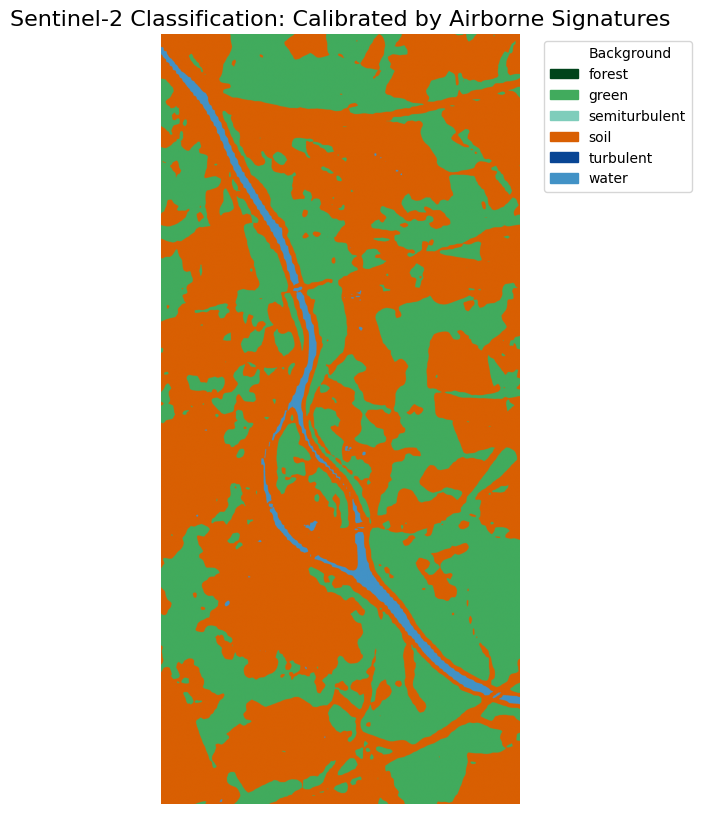


--- Classification Results ---
Forest         : 0 pixels
Green          : 3368302 pixels
Semiturbulent  : 0 pixels
Soil           : 5043501 pixels
Turbulent      : 0 pixels
Water          : 192497 pixels


In [39]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Hardcoded colors tied to class_names
# order: forest, green, semiturbulent, soil, turbulent, water
colors = ['#00441b', '#41ab5d', '#7fcdbb', '#d95f02', '#084594', '#4292c6']
cmap = ListedColormap(['#ffffff'] + colors) # White for background (-1)

plt.figure(figsize=(10, 10))
# Shift by +1 so -1 maps to index 0 (White)
plt.imshow(s2_sam_final + 1, cmap=cmap, vmin=0, vmax=len(class_names))

plt.title("Sentinel-2 Classification: Calibrated by Airborne Signatures", fontsize=16)


patches = [mpatches.Patch(color='#ffffff', label='Background')]
for i, name in enumerate(class_names):
    patches.append(mpatches.Patch(color=colors[i], label=name))
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.axis('off')
plt.show()

#print how many pixels were assigned to each class
unique, counts = np.unique(s2_sam_final, return_counts=True)
print("\n--- Classification Results ---")
for i, name in enumerate(class_names):
    count = dict(zip(unique, counts)).get(i, 0)
    print(f"{name.capitalize():<15}: {count} pixels")

The final result shows only 3 classes were used during classification. The missing ones are: forest, turbulent and semiturbulent.
Reasons of failure for each class:
* Forest: the spectral signature of forest was almost the same as for the green class. Since green class was "brighter" and had higher values it was automatically assigned for each forest pixel.
* Turbulent: the spectral signature of turbulent was almost the same as for the water class. Since water class was "darker" and has lower (and easier to distinguish form green and soil) values it was automatically assigned for most of turbulent pixels. Some of them were also classified as soil, which might have happen because of the pixel spectrum being more similar to soil than water (and not special enough to create its own class sadly.)
* Semiturbulent: same as for turbulent. This class was the smallest in the mean of potential pixel classification. I have created it just out of curiosity without high hopes.

### This case shows that SAM method may not be the most correct way to distinguish subtle changes in spectral signatures.